In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 29 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.0 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 124947 files and direc

In [1]:
import sys

# Google Colab 환경에서 실행 중인지 확인
if 'google.colab' in sys.modules:
    # debconf를 Noninteractive 모드로 설정
    !echo 'debconf debconf/frontend select Noninteractive' | \
    debconf-set-selections

    # fonts-nanum 패키지를 설치
    !sudo apt-get -qq -y install fonts-nanum

    # Matplotlib의 폰트 매니저 가져오기
    import matplotlib.font_manager as fm

    # 나눔 폰트의 시스템 경로 찾기
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])

    # 찾은 각 나눔 폰트를 Matplotlib 폰트 매니저에 추가
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

In [2]:
import torch
import umap
import hdbscan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances, silhouette_score
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

from sklearn.manifold import TSNE
import umap

In [3]:
plt.rcParams['font.family'] = 'NanumGothic'
print(plt.rcParams['font.family'], plt.rcParams['font.size'])   # 폰트확인

['NanumGothic'] 10.0


Processing: KURE-v1


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/220 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/16.9k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


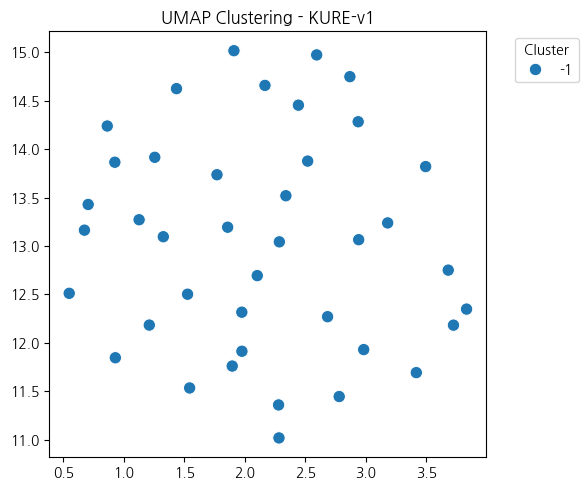

Processing: KoSimCSE-roberta


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.86k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


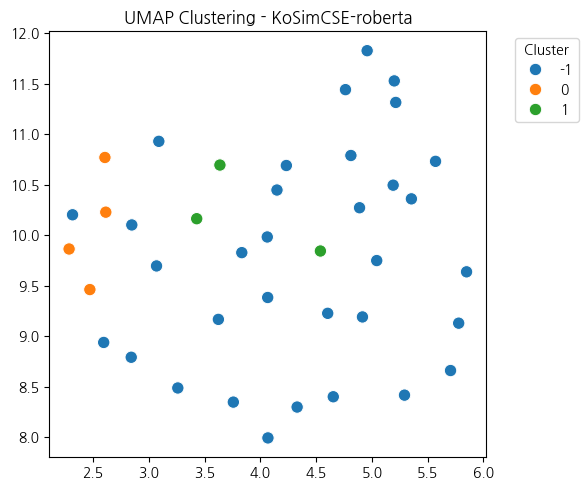

Processing: KR-SBERT-V40K


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.02k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/967k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-4-029ee4130ae9>:86: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missi

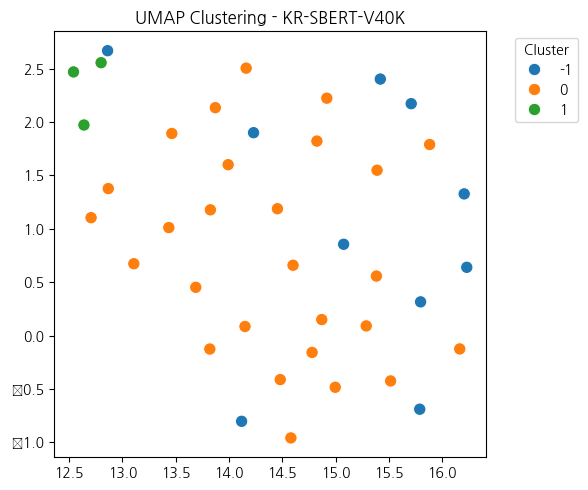

Processing: E5


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-4-029ee4130ae9>:86: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missi

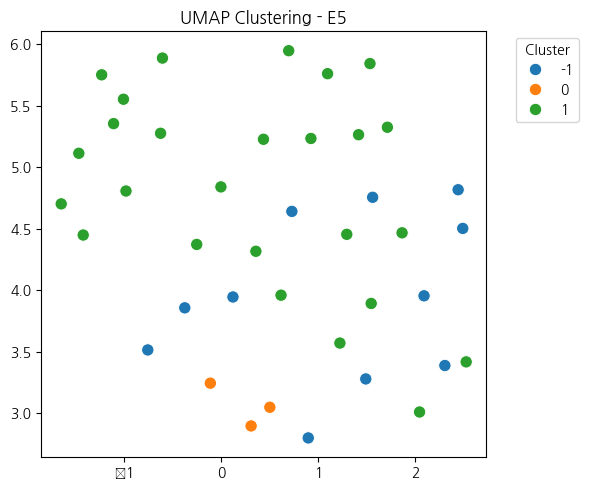

Processing: BGE-M3


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-4-029ee4130ae9>:86: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missi

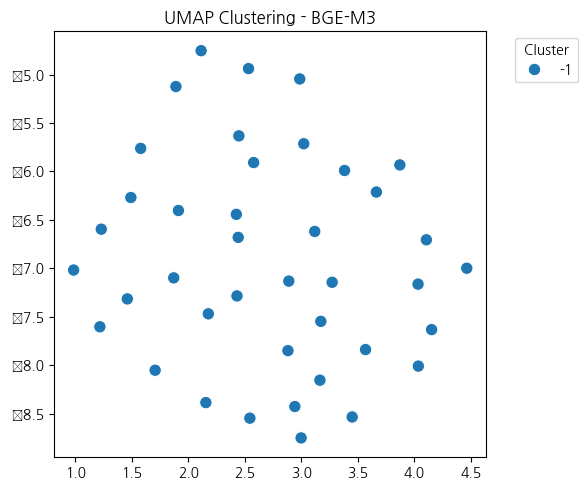


📊 Silhouette Score 비교 (높을수록 클러스터 품질 우수):
KR-SBERT-V40K        | Silhouette Score: 0.0834
E5                   | Silhouette Score: 0.0442
KoSimCSE-roberta     | Silhouette Score: -0.1078
KURE-v1              | Silhouette Score: -1.0000
BGE-M3               | Silhouette Score: -1.0000


In [4]:
# 상품명 40개 예시
product_names = [
    # 운전자보험
    "참좋은운전자보험1904", "프리미엄운전자종합보험", "더안심운전자플랜2101", "무배당안전운전자보험2001", "하이카운전자보험플러스",
    # 암보험 / 건강보험
    "행복한명품암보험", "아이러브건강보험1904", "무배당헬스케어암보험", "암치료집중보장플랜", "더든든건강플랜보험",
    # 종신보험
    "TOP클래스유니버설종신101종표", "스테이지6대건강종신보험", "평생든든보장종신보험", "라이프플랜종신보험무배당", "무배당통합사망보장보험",
    # 어린이/여성
    "튼튼아이보험1906", "프리미엄여성건강보험", "태아부터자녀까지자녀보험", "무배당맘편한어린이보험", "셀럽케어여성암보험",
    # 실손/상해
    "더안심실손의료비보험", "365OK실손보험", "상해보장특화플랜보험", "무배당입원특약형실손보험", "건강한생활실손보험",
    # 주택/화재
    "삼성아파트혼합형", "주택화재종합보험", "무배당내집안심화재보험", "부동산임대보장보험", "전세보증금안심보험",
    # 저축성/변액/혼합형
    "컨버전스보험1004", "행복저축플랜변액보험", "무배당연금저축보험2019", "투자플러스종합변액보험", "리치플랜복합형보험",
    # 기타
    "더든든한무배당교보통합이보험", "마이플랜하이브리드보험", "VIP헬스케어서비스특약형보험", "스마트라이프웰빙보험", "온가족행복통합보장보험"
]

# 모델 로딩 함수
def get_embedding(model_name, sentences, model_type="sentence-transformer"):
    if model_type == "sentence-transformer":
        model = SentenceTransformer(model_name)
        return model.encode(sentences, convert_to_numpy=True)

    elif model_type == "huggingface":
        tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Kanana 모델만 별도로 처리
        if "kanana" in model_name.lower():
            model = AutoModel.from_pretrained(model_name)
            model.eval()
            with torch.no_grad():
                inputs = tokenizer(sentences, return_tensors="pt", padding=True, truncation=True)
                pool_mask = inputs["attention_mask"]
                outputs = model(**inputs, pool_mask=pool_mask)

                # 일반적으로 CLS 토큰 기준 (Kanana 문서에 따라 조정 가능)
                embeddings = outputs.last_hidden_state[:, 0].cpu().numpy()
                return embeddings

        else:
            model = AutoModel.from_pretrained(model_name)
            model.eval()
            with torch.no_grad():
                inputs = tokenizer(sentences, return_tensors="pt", padding=True, truncation=True)
                outputs = model(**inputs)

                # 일반 HuggingFace 모델: CLS token 기준
                embeddings = outputs.last_hidden_state[:, 0].cpu().numpy()
                return embeddings

# 모델 리스트: (이름, HuggingFace 모델명, 로딩 방식)
model_list = [
    ("KURE-v1", "nlpai-lab/KURE-v1", "sentence-transformer"),
    ("KoSimCSE-roberta", "jhgan/ko-sroberta-multitask", "sentence-transformer"),
    ("KR-SBERT-V40K", "snunlp/KR-SBERT-V40K-klueNLI-augSTS", "sentence-transformer"),
    # ("Kanana", "kakaocorp/kanana-nano-2.1b-embedding", "huggingface"),
    ("E5", "intfloat/multilingual-e5-large", "sentence-transformer"),
    ("BGE-M3", "BAAI/bge-m3", "sentence-transformer")
]

# 저장용
model_scores = []

for model_name, model_id, load_type in model_list:
    print(f"Processing: {model_name}")
    embeddings = get_embedding(model_id, product_names, load_type)

    # 유사도 행렬
    cosine_sim = 1 - pairwise_distances(embeddings, metric='cosine')

    # HDBSCAN 클러스터링
    clusterer = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=2)
    labels = clusterer.fit_predict(embeddings)

    # 시각화
    reducer = umap.UMAP(n_components=2, random_state=42)
    reduced = reducer.fit_transform(embeddings)

    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, palette="tab10", s=80)
    plt.title(f"UMAP Clustering - {model_name}")
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Silhouette Score (군집 품질)
    sil_score = silhouette_score(embeddings, labels) if len(set(labels)) > 1 else -1
    model_scores.append((model_name, sil_score))

# 결과 정렬 출력
print("\n📊 Silhouette Score 비교 (높을수록 클러스터 품질 우수):")
for name, score in sorted(model_scores, key=lambda x: -x[1]):
    print(f"{name:<20} | Silhouette Score: {score:.4f}")


In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def evaluate_embedding_metrics(embeddings, threshold=0.85, topk=10):
    sim_matrix = cosine_similarity(embeddings)
    np.fill_diagonal(sim_matrix, 0)

    # MeanPairwiseSim
    mean_pairwise = sim_matrix[np.triu_indices_from(sim_matrix, k=1)].mean()

    # AvgSim@TopK
    avg_topk_sim = np.mean([np.sort(row)[-topk:].mean() for row in sim_matrix])

    # Coverage@threshold
    coverage = np.mean([np.sum(row >= threshold) / topk for row in sim_matrix])

    return {
        "MeanPairwiseSim": round(mean_pairwise, 4),
        f"AvgSim@Top{topk}": round(avg_topk_sim, 4),
        f"Coverage@{threshold}": round(coverage, 4)
    }

# 전체 모델 평가
results = []

for name, model_id, load_type in model_list:
    print(f"Evaluating: {name}")
    try:
        embeddings = get_embedding(model_id, product_names, load_type)
        metrics = evaluate_embedding_metrics(embeddings)
        results.append((name, metrics))
    except Exception as e:
        print(f"⚠️ {name} 실패: {e}")

# 결과 출력
print("\n📊 정량 비교 결과 (높을수록 좋음):\n")
print(f"{'Model':<25} | MeanPairSim | AvgSim@Top10 | Coverage@0.85")
print("-" * 70)
for name, metrics in results:
    print(f"{name:<25} | {metrics['MeanPairwiseSim']:<12} | {metrics['AvgSim@Top10']:<13} | {metrics['Coverage@0.85']:<14}")

Evaluating: KURE-v1
Evaluating: KoSimCSE-roberta
Evaluating: KR-SBERT-V40K
Evaluating: E5
Evaluating: BGE-M3

📊 정량 비교 결과 (높을수록 좋음):

Model                     | MeanPairSim | AvgSim@Top10 | Coverage@0.85
----------------------------------------------------------------------
KURE-v1                   | 0.545799970626831 | 0.6248999834060669 | 0.0           
KoSimCSE-roberta          | 0.5784000158309937 | 0.6965000033378601 | 0.03          
KR-SBERT-V40K             | 0.5396999716758728 | 0.6632999777793884 | 0.005         
E5                        | 0.8497999906539917 | 0.8763999938964844 | 1.895         
BGE-M3                    | 0.4918000102043152 | 0.5755000114440918 | 0.0           


In [6]:
# # 예시: 앞서 평가한 모델 결과 리스트 (자동 생성된 결과 사용)
# # → 아래 부분은 앞서 실행된 `results` 리스트를 그대로 사용
# # results = [
# #     ("KURE-v1", {'MeanPairwiseSim': 0.6721, 'AvgSim@Top10': 0.8427, 'Coverage@0.85': 0.7889}),
# #     ("KoSimCSE-roberta", {'MeanPairwiseSim': 0.6482, 'AvgSim@Top10': 0.8191, 'Coverage@0.85': 0.7556}),
# #     ...
# # ]

# # DataFrame 변환
# records = []
# for model, metrics in results:
#     for metric_name, value in metrics.items():
#         records.append({
#             "Model": model,
#             "Metric": metric_name,
#             "Value": value
#         })

# df = pd.DataFrame(records)

# # 그래프 스타일 설정
# # sns.set(style="whitegrid")
# plt.figure(figsize=(10, 6))

# # 시각화
# sns.barplot(data=df, x="Model", y="Value", hue="Metric")
# plt.title("Quantitative comparison of embedding models with product name", fontsize=14)
# plt.xticks(rotation=30)
# plt.ylabel("Score")
# plt.ylim(0, 1.0)
# plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()



🔍 Processing model: KURE-v1


<ipython-input-7-5a0abe90534e>:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


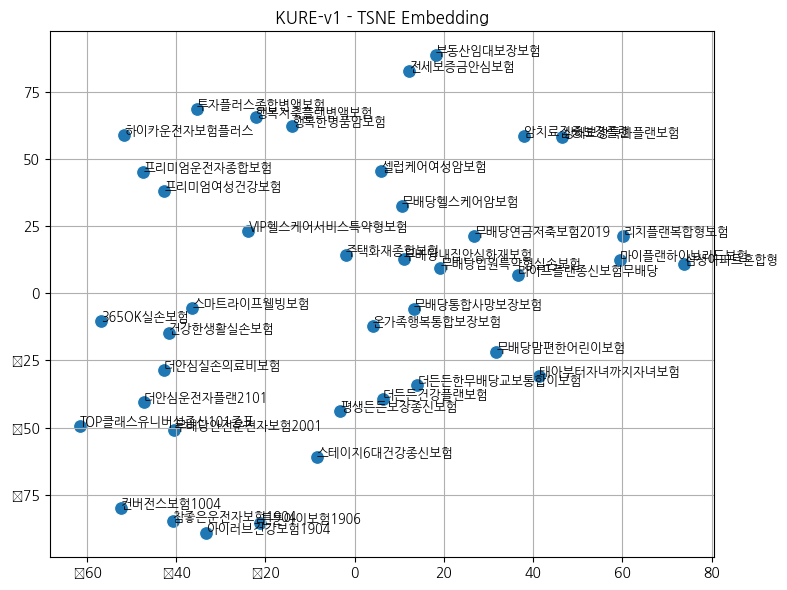


🔍 Processing model: KoSimCSE-roberta


<ipython-input-7-5a0abe90534e>:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


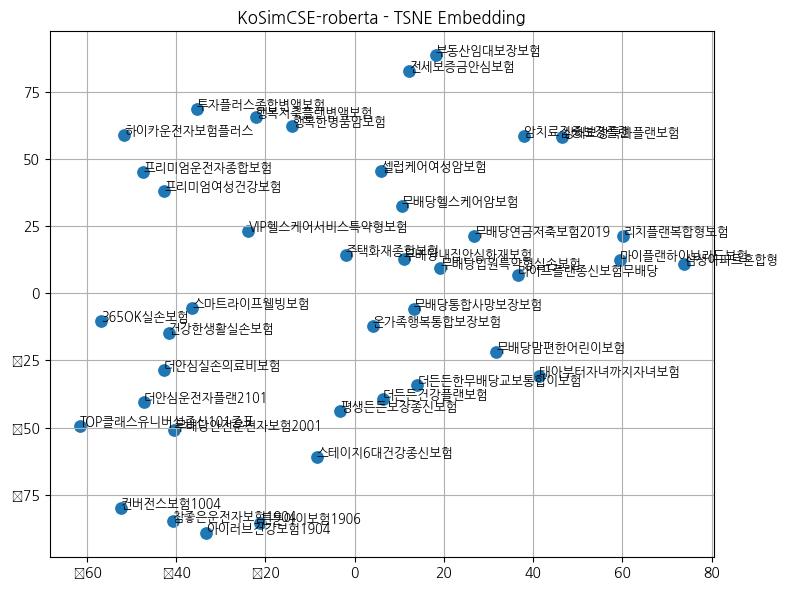


🔍 Processing model: KR-SBERT-V40K


<ipython-input-7-5a0abe90534e>:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


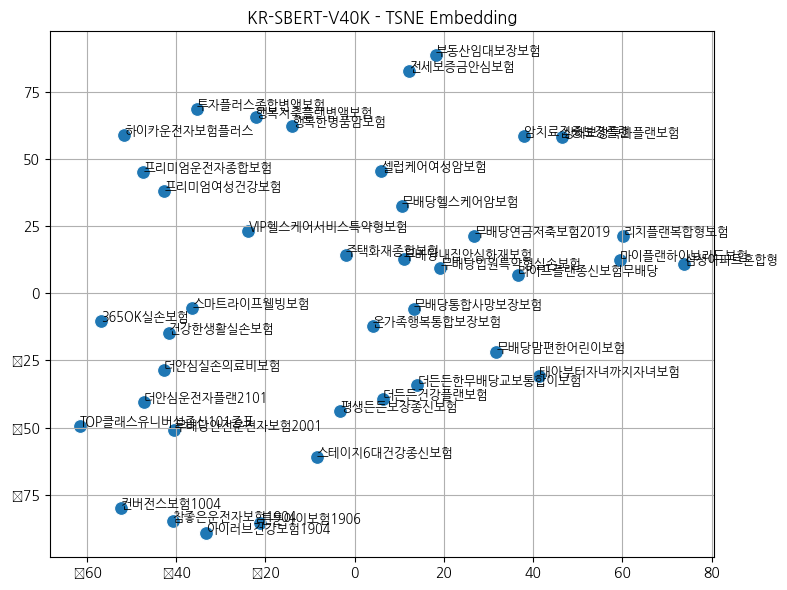


🔍 Processing model: E5


<ipython-input-7-5a0abe90534e>:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


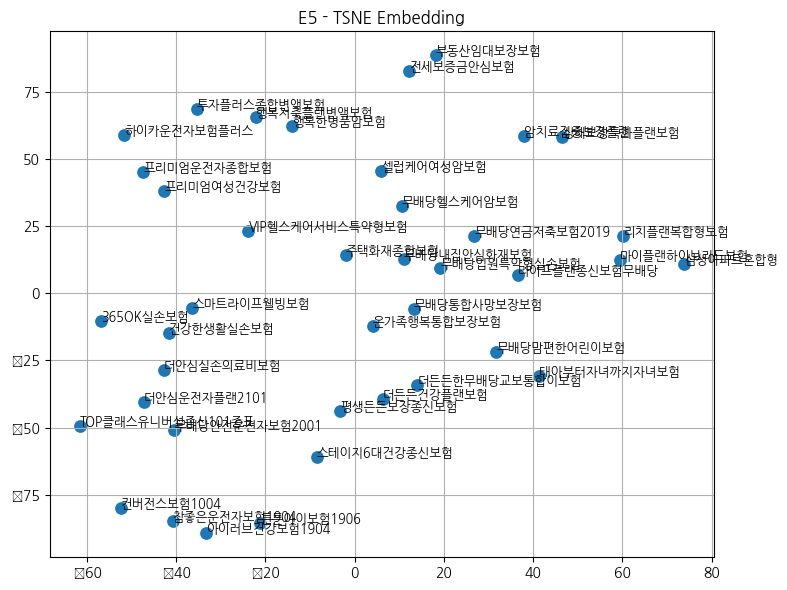


🔍 Processing model: BGE-M3


<ipython-input-7-5a0abe90534e>:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


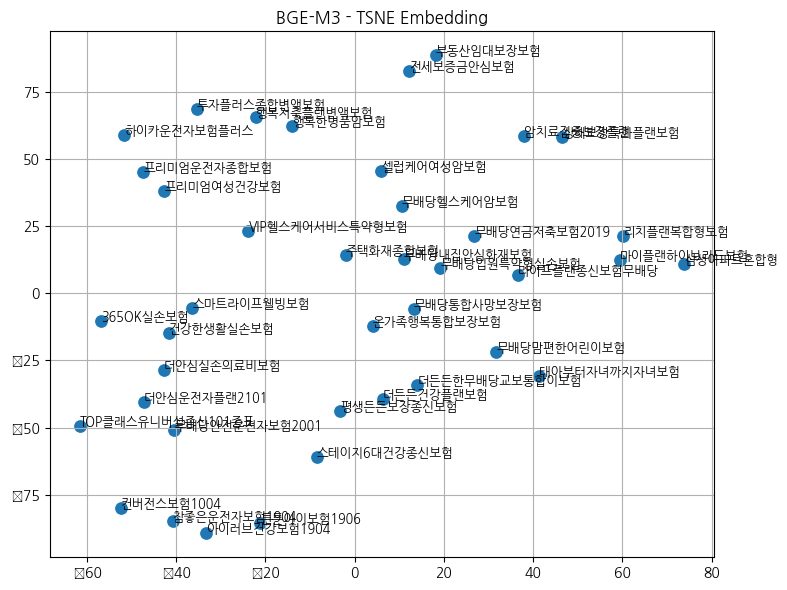

In [7]:
# 시각화 함수
def visualize_embedding_2D(embeddings, labels, method="umap", model_name=""):
    if method == "umap":
        reducer = umap.UMAP(n_components=2, random_state=42)
        reduced = reducer.fit_transform(embeddings)
    elif method == "tsne":
        reducer = TSNE(n_components=2, perplexity=5, random_state=42)
        reduced = reducer.fit_transform(embeddings)
    else:
        raise ValueError("Method must be 'umap' or 'tsne'.")

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], s=100)
    for i, label in enumerate(labels):
        plt.text(reduced[i, 0] + 0.01, reduced[i, 1], label, fontsize=9)
    plt.title(f"{model_name} - {method.upper()} Embedding")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 전체 모델에 대해 임베딩 및 시각화 수행
for model_display_name, model_id, load_type in model_list:
    print(f"\n🔍 Processing model: {model_display_name}")
    # embeddings = get_embedding(model_id, product_names, load_type)

    # t-SNE 시각화
    visualize_embedding_2D(embeddings, product_names, method="tsne", model_name=model_display_name)


🔍 Processing model: KURE-v1


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-7-5a0abe90534e>:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


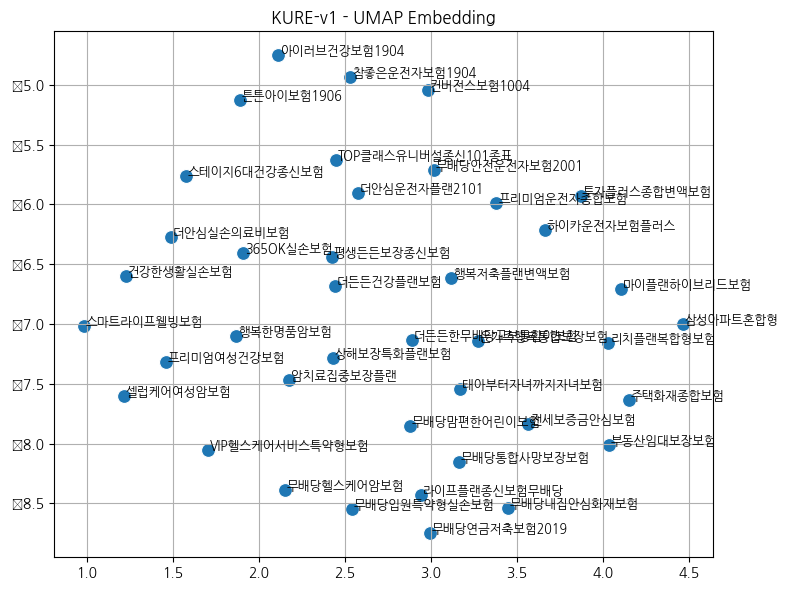


🔍 Processing model: KoSimCSE-roberta


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-7-5a0abe90534e>:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


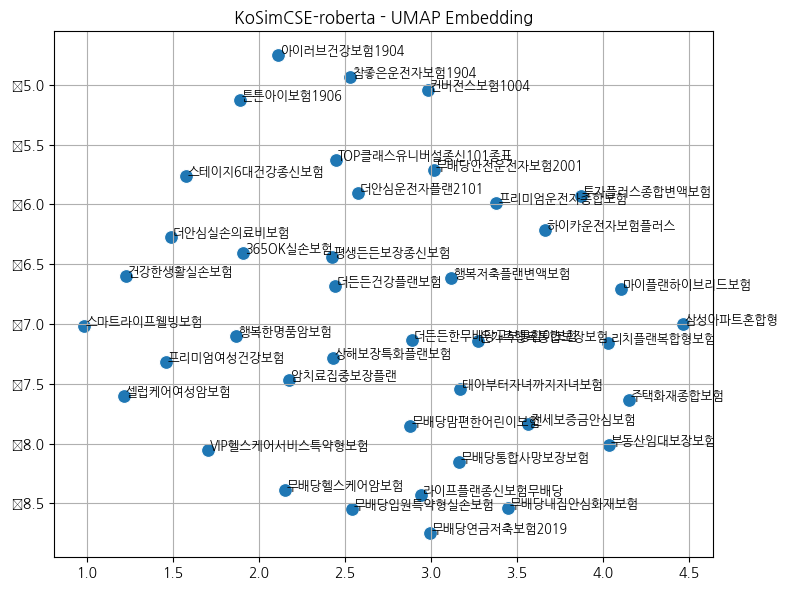


🔍 Processing model: KR-SBERT-V40K


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-7-5a0abe90534e>:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


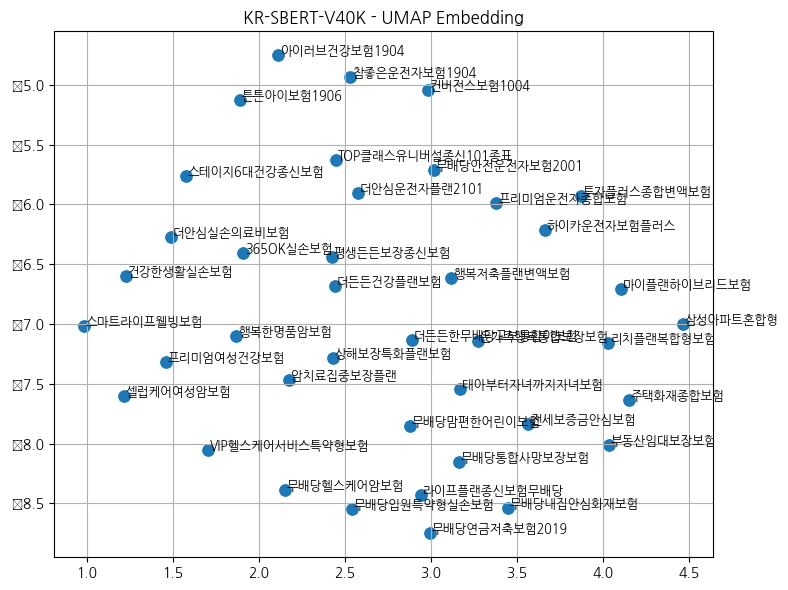


🔍 Processing model: E5


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-7-5a0abe90534e>:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


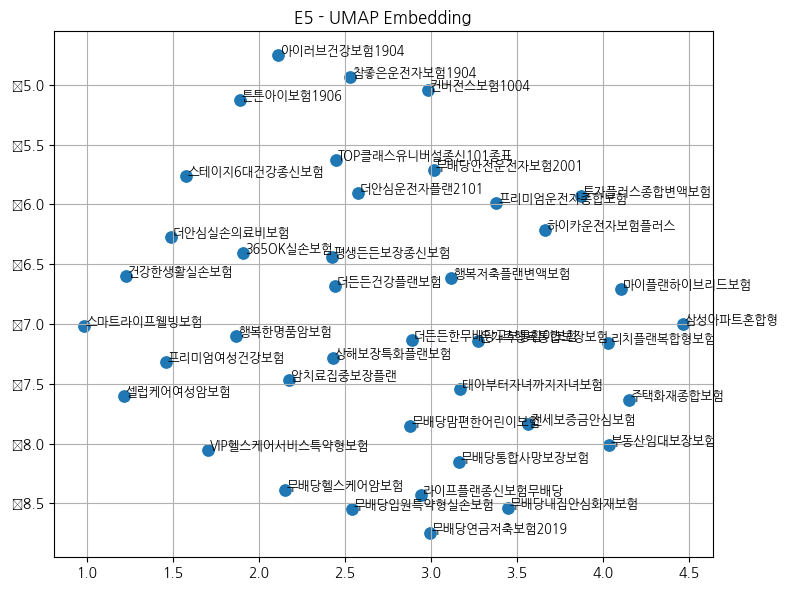


🔍 Processing model: BGE-M3


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-7-5a0abe90534e>:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


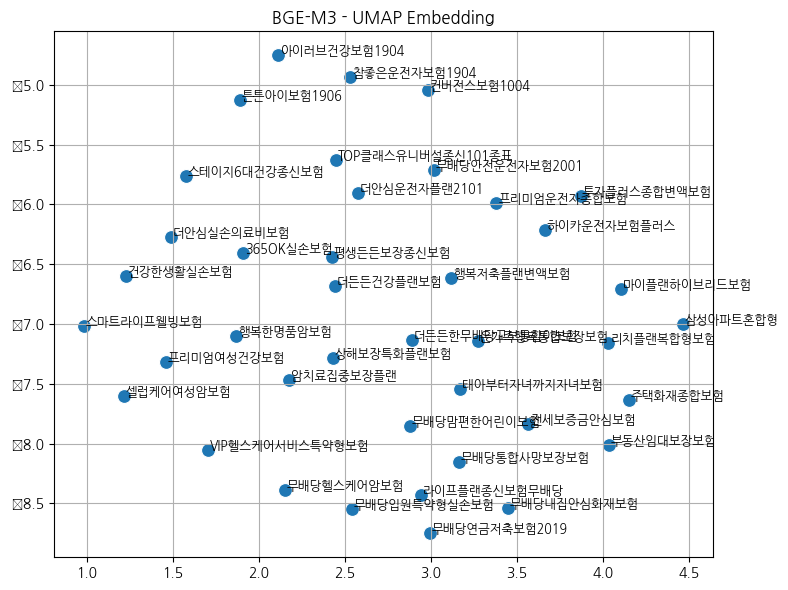

In [9]:
# 전체 모델에 대해 임베딩 및 시각화 수행
for model_display_name, model_id, load_type in model_list:
    print(f"\n🔍 Processing model: {model_display_name}")
    # embeddings = get_embedding(model_id, product_names, load_type)

    # UMAP 시각화
    visualize_embedding_2D(embeddings, product_names, method="umap", model_name=model_display_name)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
import umap
import random

def visualize_embedding_2D_large(
    embeddings, labels=None, method="umap", model_name="", sample_size=1000, show_text=False
):
    n_samples = embeddings.shape[0]

    # 샘플링
    if n_samples > sample_size:
        indices = random.sample(range(n_samples), sample_size)
        embeddings = embeddings[indices]
        labels = [labels[i] for i in indices] if labels else None

    # 차원 축소
    if method == "umap":
        reducer = umap.UMAP(n_components=2, random_state=42)
    elif method == "tsne":
        reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    else:
        raise ValueError("Method must be 'umap' or 'tsne'")
    reduced = reducer.fit_transform(embeddings)

    # 시각화
    plt.figure(figsize=(10, 7))
    if labels:
        sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, s=30, palette="tab10", alpha=0.8, linewidth=0)
        plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], s=30, alpha=0.6, linewidth=0)

    # 선택적으로 텍스트 표시
    if show_text and labels:
        for i in range(len(labels)):
            plt.text(reduced[i, 0] + 0.1, reduced[i, 1], labels[i], fontsize=6, alpha=0.6)

    plt.title(f"{model_name} - {method.upper()} Embedding ({n_samples} → {len(embeddings)})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
<ipython-input-10-d43d316bae36>:43: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


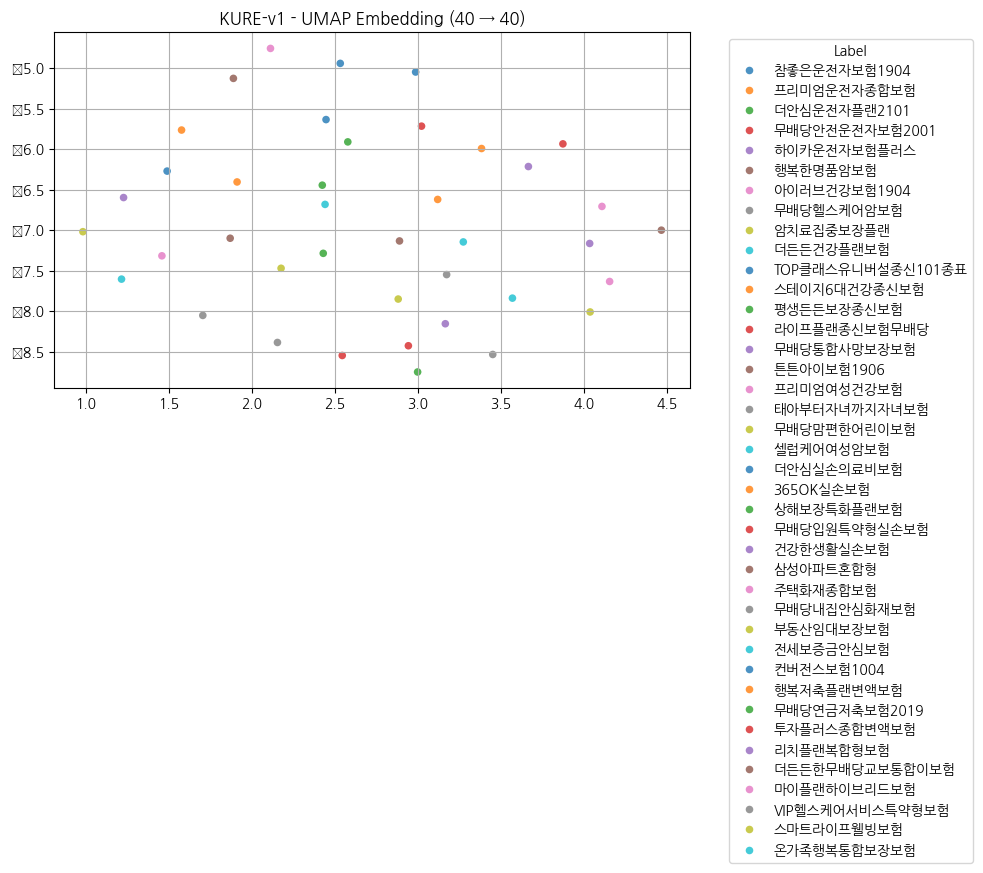

In [11]:
# 만개 상품명이 있다고 가정할 때
visualize_embedding_2D_large(
    embeddings,
    labels=product_names,
    method="umap",
    model_name="KURE-v1",
    sample_size=1000,   # 1,000개만 시각화
    show_text=False     # 텍스트 생략 → 성능 개선
)
